# T-maze

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* T-maze
* Agent navigation is largely fixed based on a randomly selected target arm for each trajectory.
* Target object initially located near end of one arm.
* Two-compartment pyramidal neuron layer:
  * Somatic input: jittered, but uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
import importlib
from pathlib import Path
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, learn_util, plot_util, params_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "t_maze"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## 1. Initial target location

In [5]:
env_params = params_util.get_env_params(
    environment="tmaze",
)

agent_params = params_util.get_agent_params(
    environment="tmaze", left_arm_prop=1,
)

PC_params = params_util.get_PC_params(
    environment="tmaze", 
    place_cell_centres="uniform", #"uniform_jitter"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
)

100%|██████████████████████████████████████| 8000/8000 [00:15<00:00, 505.30it/s]


Finishing last trajectory.


262it [00:00, 527.78it/s]


Only reached target 6 times (target: 10).
Trajectory lengths (12) to date: 20.66 +/- 6.37 sec each
Trajectory lengths (12) to date: 688.58 +/- 212.40 steps each
1 BTSP events triggered (allowed from steps 0 to 8262): occurred at step 634.


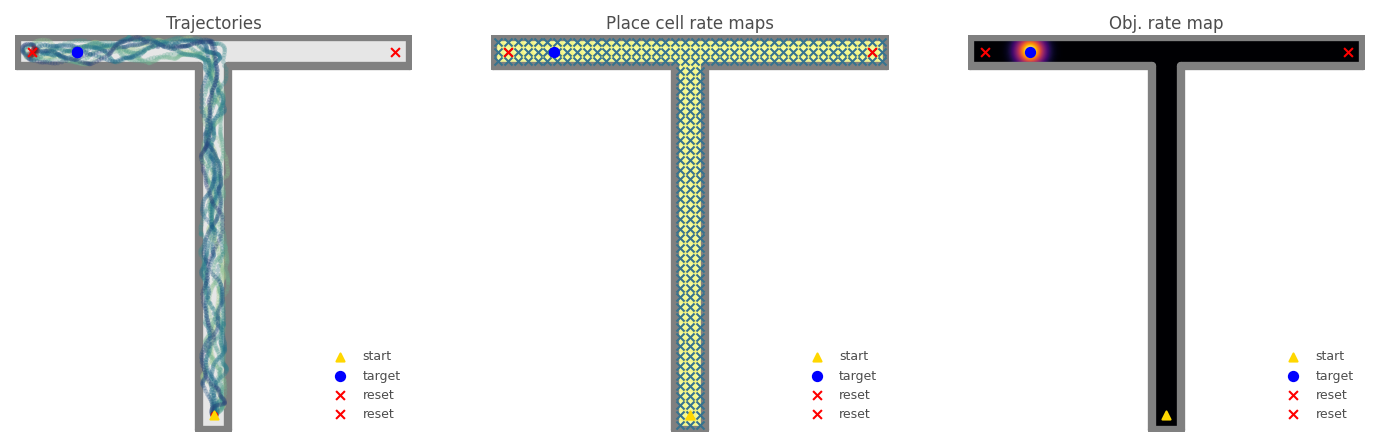

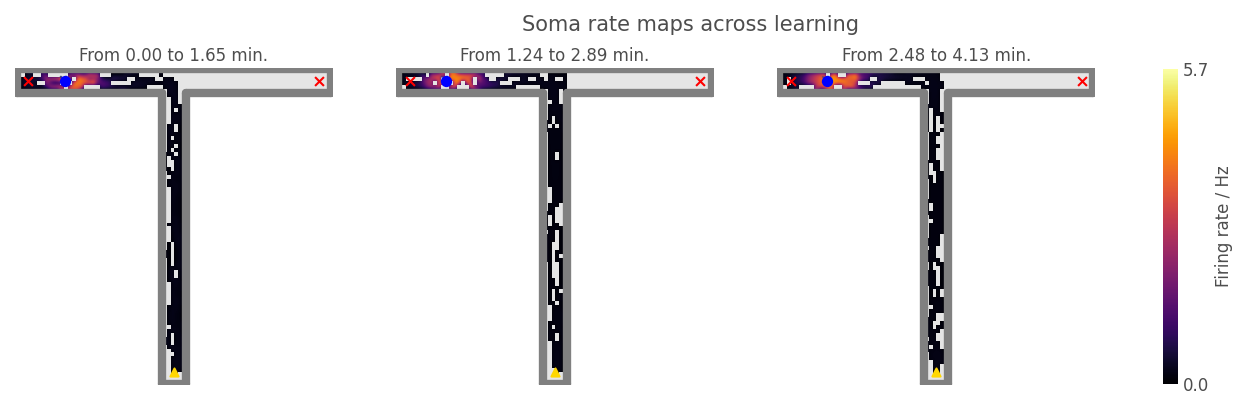

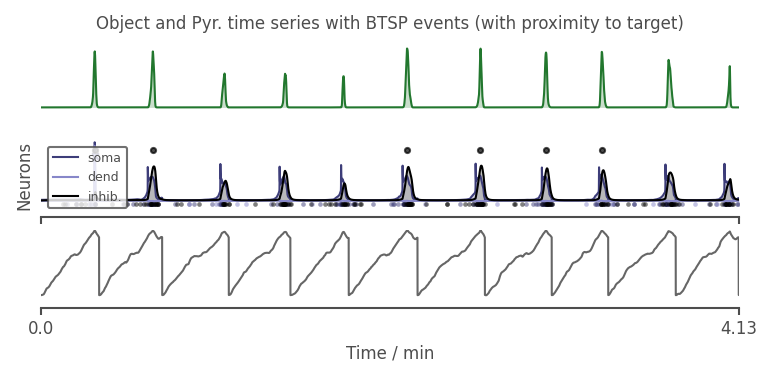

In [6]:
learner, spatial_axes, rate_maps_axes, BTSP_sub_ax = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_target_reaches=10,
    max_num_steps=8000, 
    use_Hebbian=False,
    BTSP_on=0,
)

Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(learner.Pyrs)

ALL_FIGURES["1-initial_spatial"] = spatial_axes
ALL_FIGURES["1-initial_rate_maps"] = rate_maps_axes
ALL_FIGURES["1-initial_BTSP_proximity"] = BTSP_sub_ax

Linear speed mean: 26.73 cm/s, std: 10.78 cm/s.


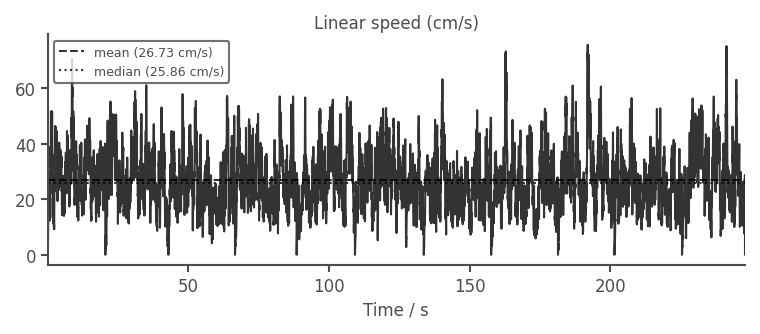

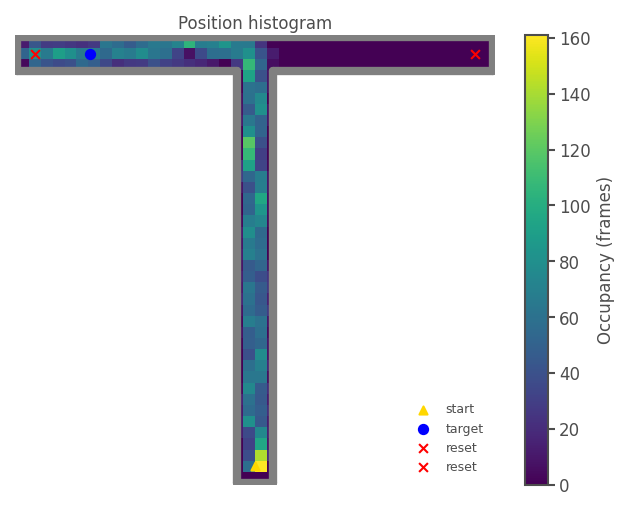

In [7]:
learner.Agent.log_speed_stats()
sub_ax_speed = learner.Agent.plot_speed(mark_mean=True, mark_median=True)
sub_ax_occ = learner.Agent.plot_occupancy()

ALL_FIGURES["1-initial_speed"] = sub_ax_speed
ALL_FIGURES["1-initial_occupancy"] = sub_ax_occ

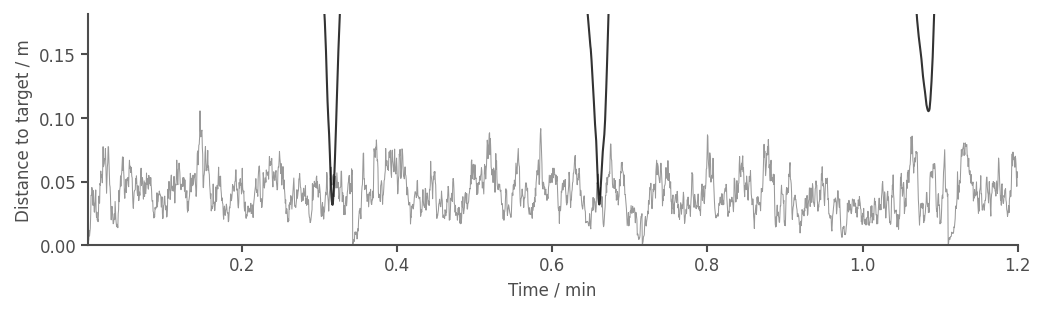

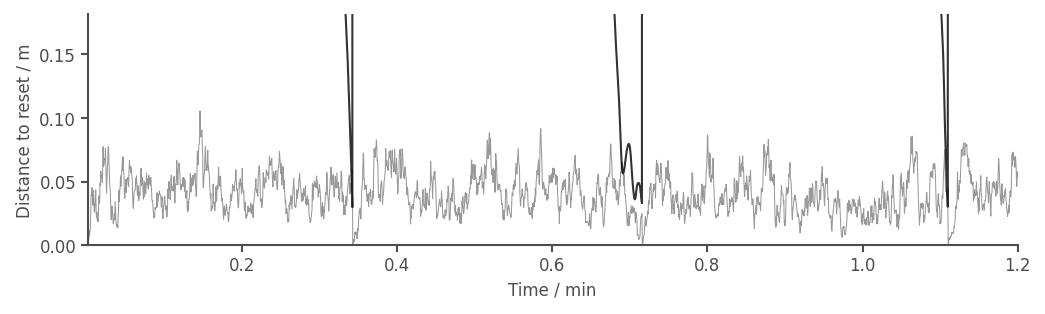

In [8]:
zoom_prop = 1.6
time_max = 1.2

sub_ax_target = learner.Agent.plot_distance_to(zoom_prop=zoom_prop)
sub_ax_reset = learner.Agent.plot_distance_to(
    zoom_prop=zoom_prop,
    position=learner.Agent.reset_position[0], 
    position_name="reset",
    tol_prop_to_speed_dt=learner.Agent.reset_reached_within_tol_prop_to_speed_dt
)
sub_ax_target.set_xlim(None, time_max)
sub_ax_reset.set_xlim(None, time_max)

ALL_FIGURES["1-initial_distance_to_target"] = sub_ax_target
ALL_FIGURES["1-initial_distance_to_reset"] = sub_ax_reset

In [9]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 537.00 steps (16.11 sec.)
No neuron had at least two BTSP events triggered.


### Place cell rate maps

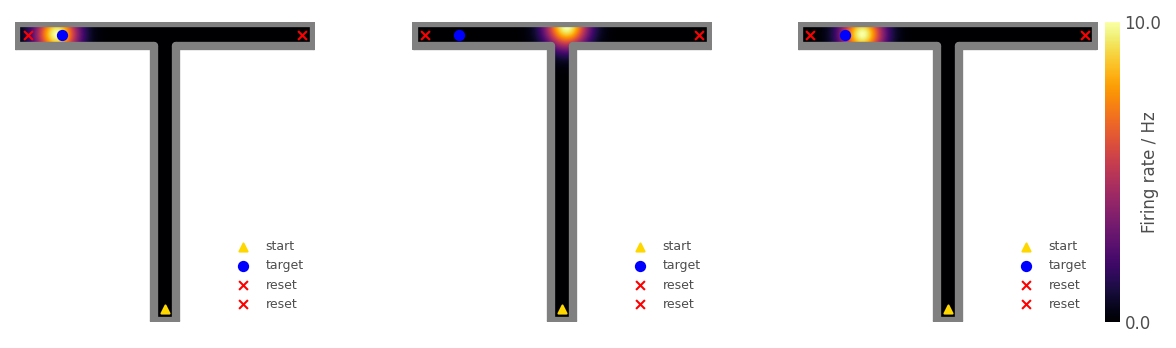

In [10]:
num_plots = 3
chosen_neurons = np.random.choice(learner.PCs.n, 3, replace=False)
_, ax1D = plt.subplots(1, num_plots, figsize=(num_plots * 2.5, 2))
learner.PCs.plot_rate_map(chosen_neurons=chosen_neurons, ax=ax1D)

ALL_FIGURES["1-initial_PC_rate_maps"] = ax1D

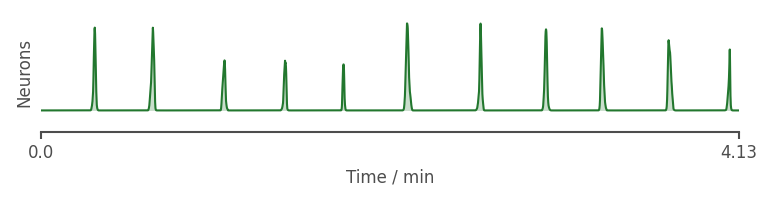

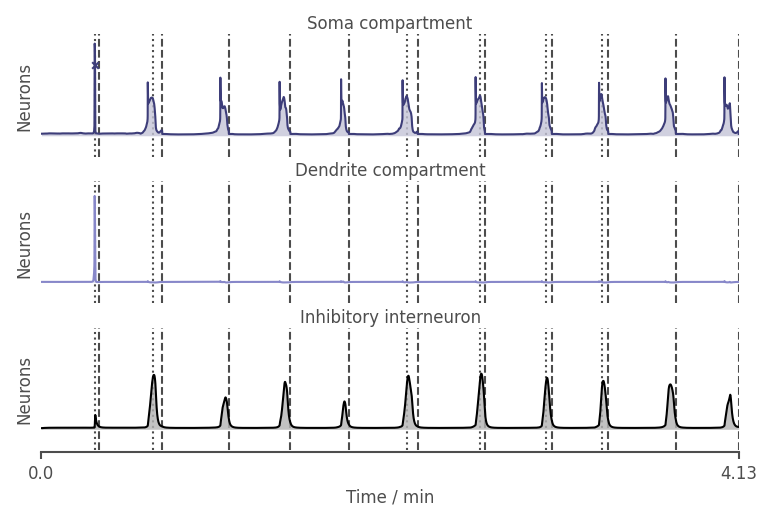

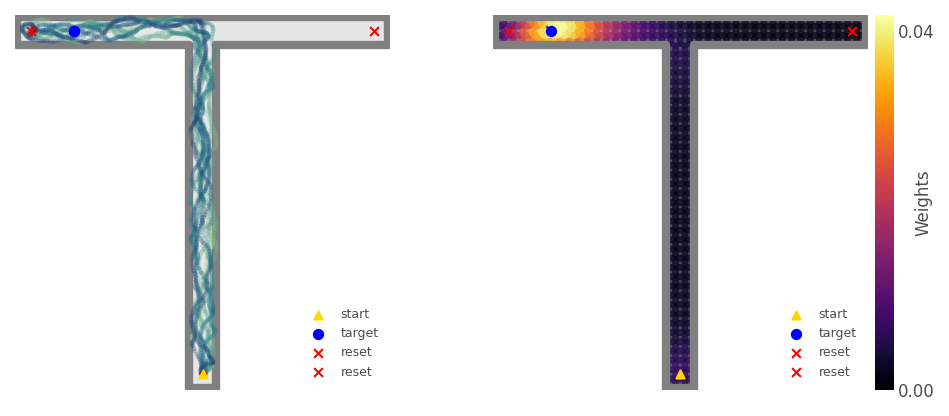

In [11]:
fig, sub_ax = plt.subplots(figsize=[6, 1])
learner.Objs.plot_rate_timeseries(sub_ax=sub_ax)

axes = learner.Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner.Agent.plot_trajectories(scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["1-initial_obj_timeseries"] = sub_ax
ALL_FIGURES["1-initial_timeseries"] = axes
ALL_FIGURES["1-initial_trajectory_weights"] = ax1D

### Assessments based on theoretical kernel

/home/cgillon/homedir/predhpc/predhpc/util/learn_util.py:830: UserWarning: Assessment will assume geodesic wall geometry even though place cell wall geometry is line_of_sight.
  warnings.warn(


Update 1 regul.: 6.9208 (w)


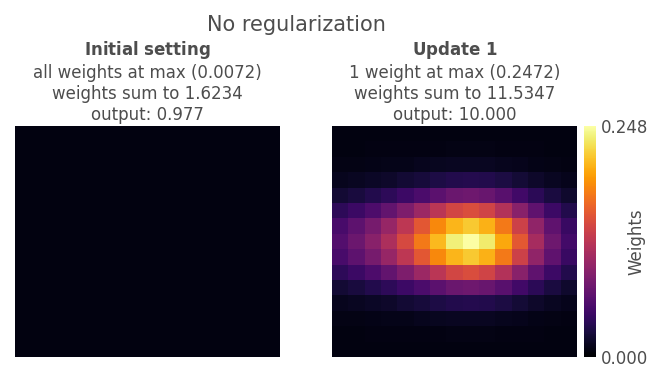

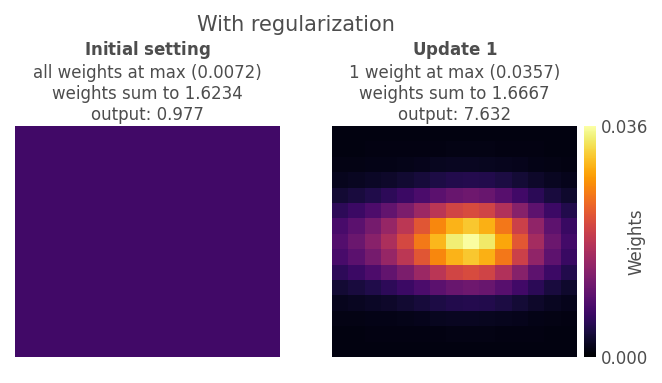

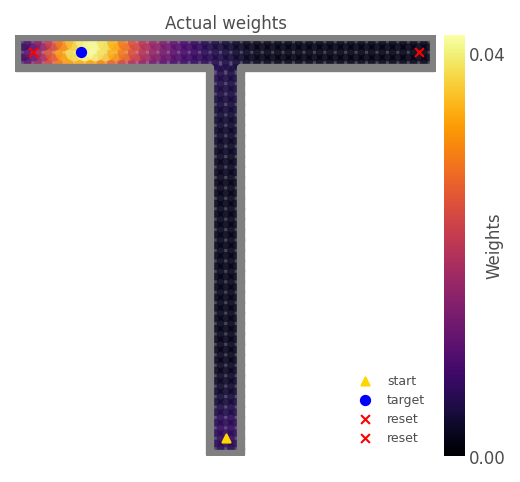

In [12]:
OUTPUT_FR = 6 # tuned to match actual weights as closely as possible

for normalize_weights_divisively in [False, True]:
    assessment_dict = learn_util.assess_Pyrs_lr_factors(
        learner.Pyrs.SomaCompartment, 
        normalize_weights_divisively=normalize_weights_divisively, 
        output_fr=OUTPUT_FR, 
        log_reg=True,
    )
    axes = plot_util.plot_lr_factor_assessment(assessment_dict)
    title_str = "With" if normalize_weights_divisively else "No"
    axes.ravel()[0].figure.suptitle(f"{title_str} regularization", y=1.25)

    norm_str = "_norm" if normalize_weights_divisively else ""
    ALL_FIGURES[f"1-initial_kernal{norm_str}"] = axes

fig, sub_ax = plt.subplots(figsize=(3, 3))
plot_fcts.plot_2D_input_place_cell_weights(learner.Pyrs.SomaCompartment, ax=sub_ax)
sub_ax.set_title("Actual weights")
ALL_FIGURES["1-initial_weights_small"] = sub_ax

BTSP events applied after 537.00 steps (16.11 sec.) (num steps: 537).


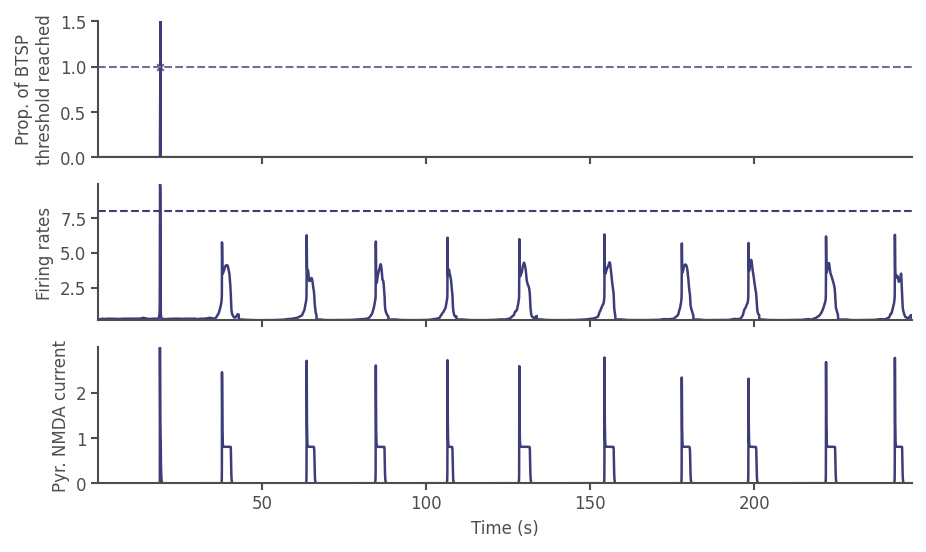

In [13]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
ax1D = learner.Pyrs.SomaCompartment.plot_BTSP_ramp()

ALL_FIGURES["1-initial_BTSP_timeseries"] = ax1D

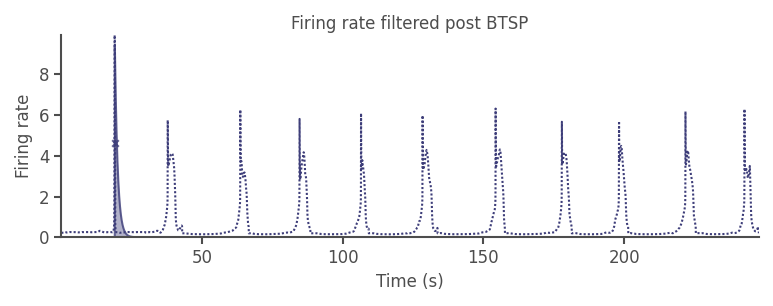

In [14]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["1-initial_post_BTSP_filter"] = sub_ax

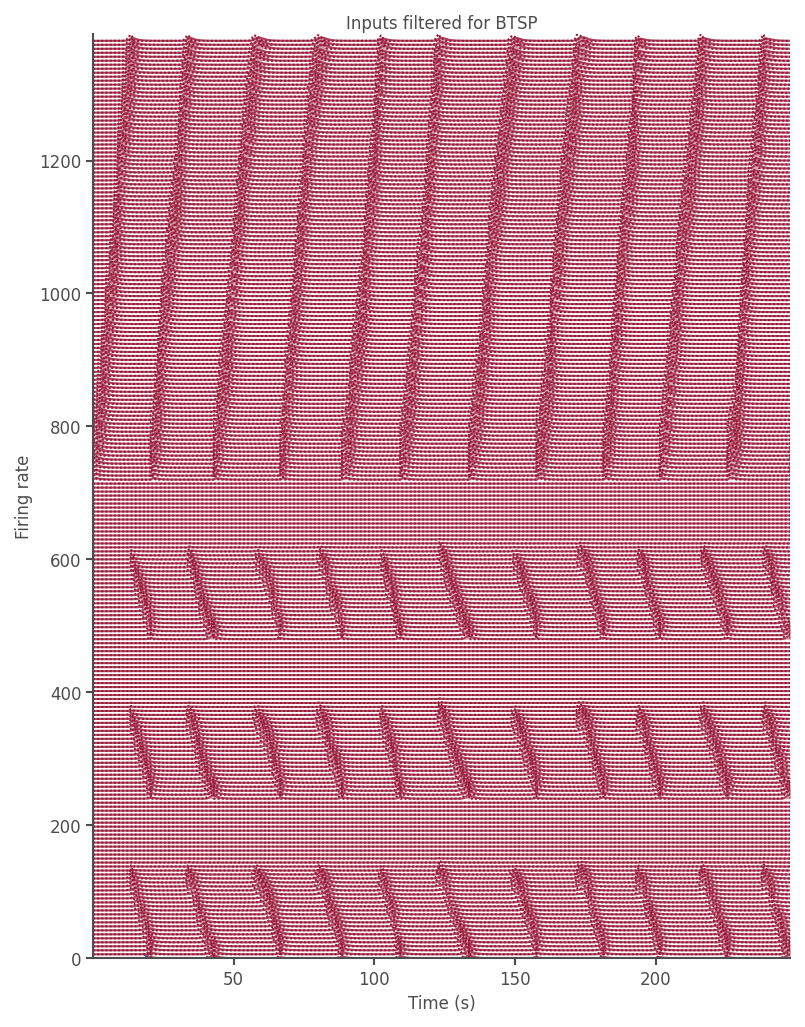

In [15]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs", rasterize_shading=True)
ALL_FIGURES["1-initial_pre_BTSP_filter"] = sub_ax

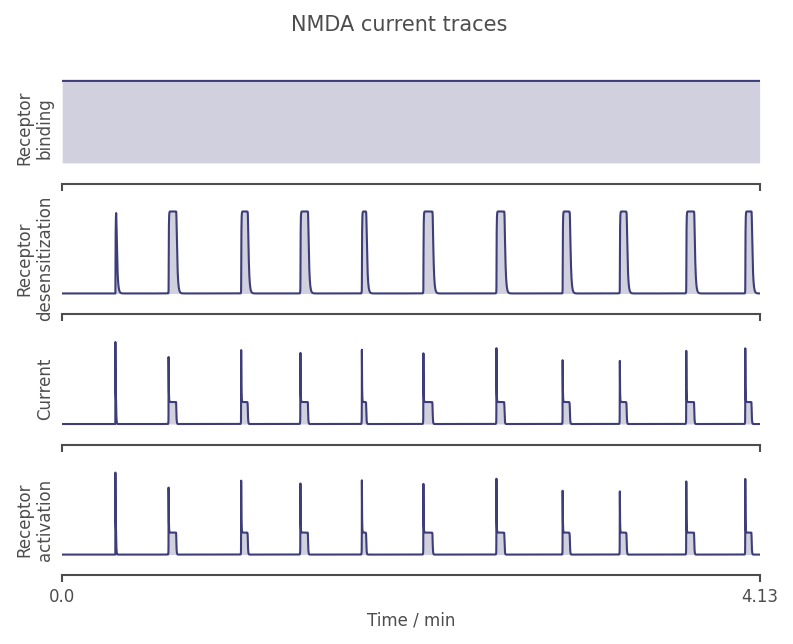

In [16]:
ax1D = learner.Pyrs.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all")
ALL_FIGURES["1-initial_NMDA_current"] = ax1D

In [17]:
learner.Agent.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.6125,3.85,0,0.00,629.0,18.87,629.0,18.87
1,left,0.6125,3.85,629,18.87,1317.0,39.51,688.0,20.64
2,left,0.6125,3.85,1317,39.51,4328.0,129.84,3011.0,90.33
3,left,0.6125,3.85,4328,129.84,5199.0,155.97,871.0,26.13
4,left,0.6125,3.85,5199,155.97,5979.0,179.37,780.0,23.40
5,left,0.6125,3.85,5979,179.37,6637.0,199.11,658.0,19.74
6,left,0.6125,3.85,6637,199.11,NaN,NaN,NaN,NaN


In [18]:
learner.Agent.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,2.004505,0.153357,0,0.00,0.170762,3.870925,684.0,20.52,684.0,20.52
1,1.996791,0.144419,684,20.52,0.182921,3.870925,1431.0,42.93,747.0,22.41
2,1.994781,0.148214,1431,42.93,0.177431,3.870925,2220.0,66.60,789.0,23.67
3,2.000000,0.154960,2220,66.60,0.132163,3.870925,2950.0,88.50,730.0,21.90
4,2.005171,0.149222,2950,88.50,0.135432,3.870925,3641.0,109.23,691.0,20.73
5,2.004878,0.152528,3641,109.23,0.151188,3.870925,4456.0,133.68,815.0,24.45
6,2.002228,0.146417,4456,133.68,0.161325,3.870925,5254.0,157.62,798.0,23.94
7,2.001815,0.155437,5254,157.62,0.176116,3.870925,6046.0,181.38,792.0,23.76
8,2.003614,0.147946,6046,181.38,0.176943,3.870925,6715.0,201.45,669.0,20.07
9,2.005388,0.152424,6715,201.45,0.181307,3.870925,7515.0,225.45,800.0,24.00


## 2. Move target

In [19]:
Ag = learner.Agent
Pyrs = learner.Pyrs

move_time = Ag.t
Ag.set_target_position([Env.scale_x / 2, Env.scale_y / 2])

In [20]:
NUM_STEPS = 5000

learner_move = run_manager.learn_T_maze_BTSP(
    Pyrs=Pyrs,
    num_target_reaches=10,
    max_num_steps=5000,
    use_Hebbian=False,
    BTSP_on=0,
    plot=False,
);

100%|██████████████████████████████████████| 5000/5000 [00:10<00:00, 484.75it/s]


Finishing last trajectory.


725it [00:01, 532.52it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (19) to date: 22.09 +/- 5.68 sec each
Trajectory lengths (19) to date: 736.26 +/- 189.19 steps each
1 BTSP events triggered (allowed from steps 8263 to 13988): occurred at step 10154.


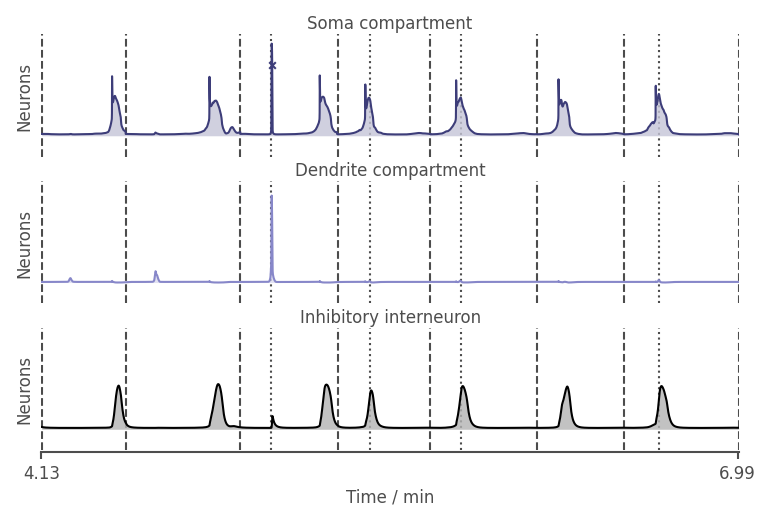

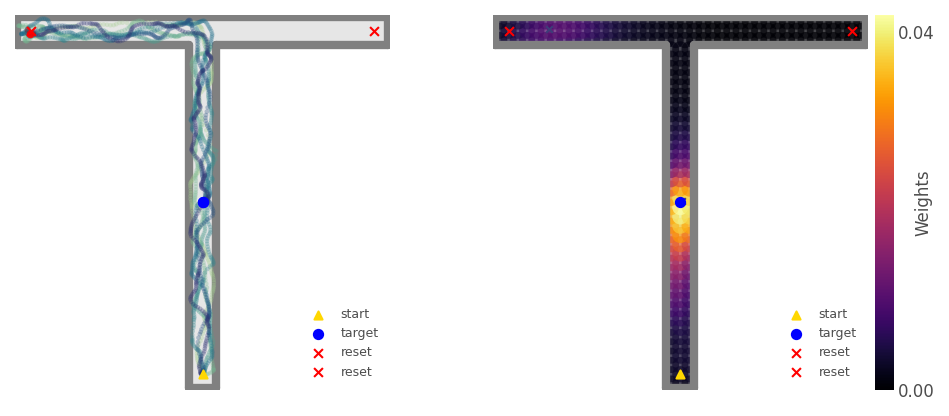

In [21]:
ts_axes = learner_move.Pyrs.plot_rate_timeseries(t_start=move_time, separate_axes=True, norm_by="shared_max")

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner_move.Agent.plot_trajectories(t_start=move_time, scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner_move.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["2-moved_timeseries"] = ts_axes
ALL_FIGURES["2-moved_trajectory_weights"] = ax1D

## 3. Test inhibition hyperparameter

### a. Insufficient dendritic self-inhibition
Multiple BTSP events is similar locations

In [22]:
LOW_INHIBIT_WEIGHT = 0.6

Pyr_params_low = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    inhibit_weight=LOW_INHIBIT_WEIGHT,
)

100%|██████████████████████████████████████| 6000/6000 [00:11<00:00, 504.06it/s]


Finishing last trajectory.


300it [00:00, 520.72it/s]


Only reached target 5 times (target: 12).
Trajectory lengths (9) to date: 21.00 +/- 7.75 sec each
Trajectory lengths (9) to date: 700.11 +/- 258.24 steps each
6 BTSP events triggered (allowed from steps 0 to 6300): occurred between steps 1436 and 6087, inclusively.


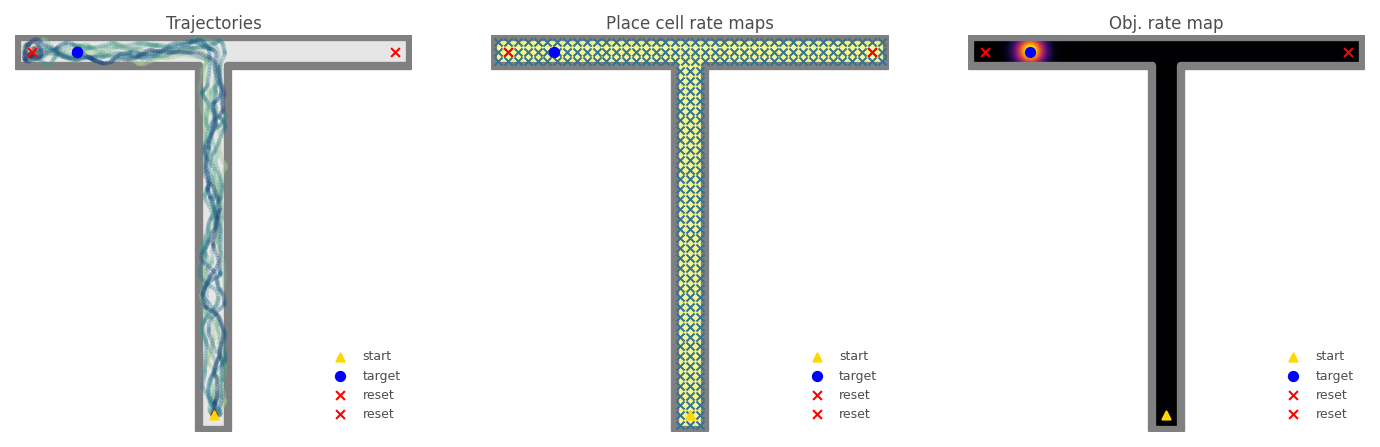

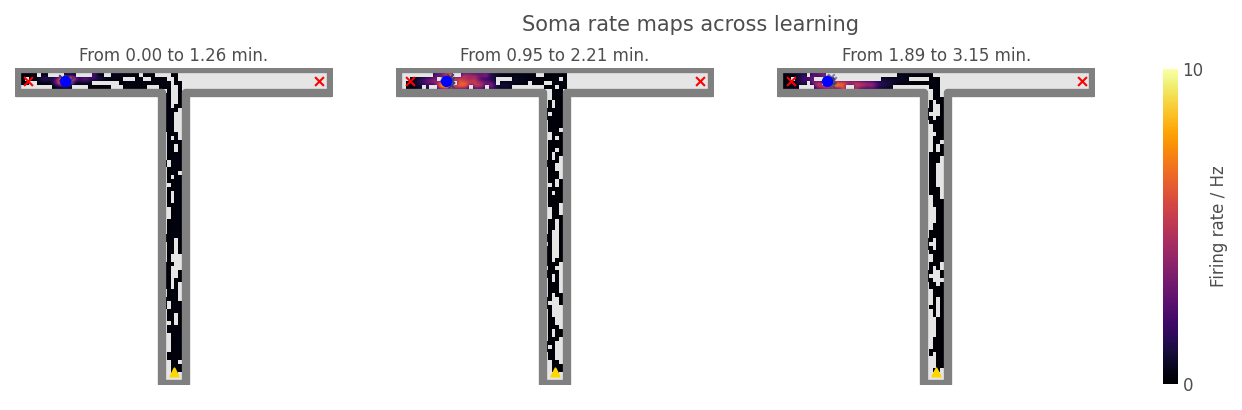

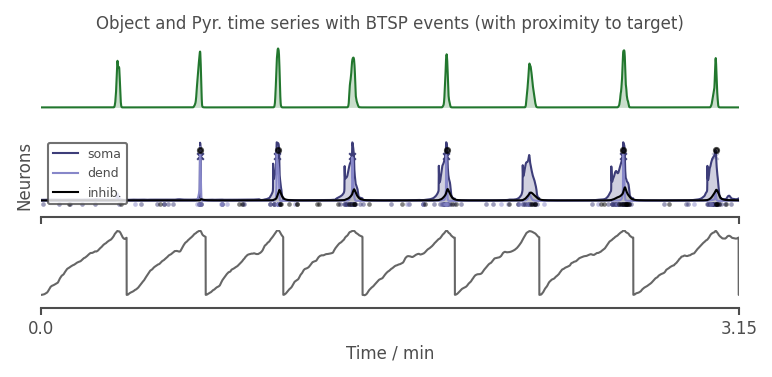

In [23]:
learner_low, spatial_axes, rate_maps_axes, BTSP_sub_ax = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params_low, 
    num_target_reaches=12, 
    max_num_steps=6000,
    use_Hebbian=False,
)

ALL_FIGURES["3-low_inhib_spatial"] = spatial_axes
ALL_FIGURES["3-low_inhib_rate_maps"] = rate_maps_axes
ALL_FIGURES["3-low_inhib_BTSP_proximity"] = BTSP_sub_ax

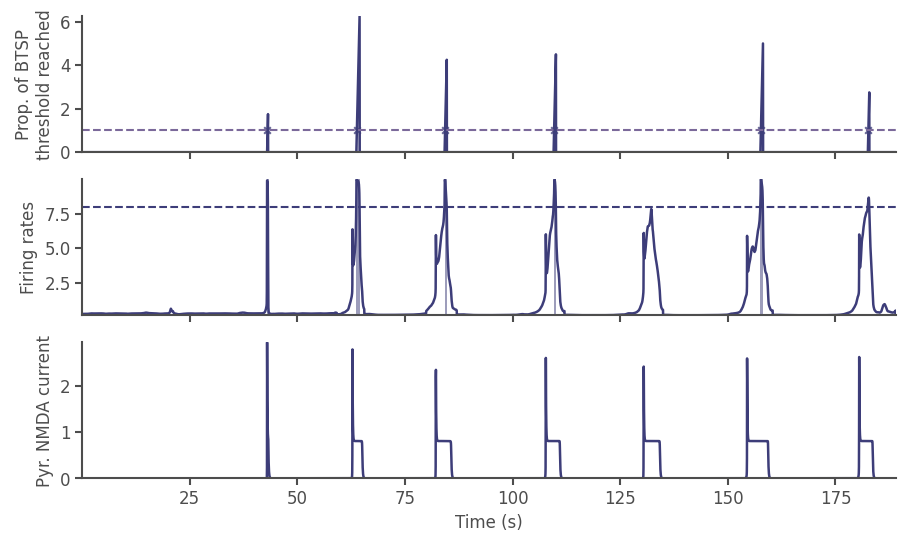

In [24]:
axes = learner_low.Pyrs.SomaCompartment.plot_BTSP_ramp()
ALL_FIGURES["3-low_inhib_BTSP_timeseries"] = axes

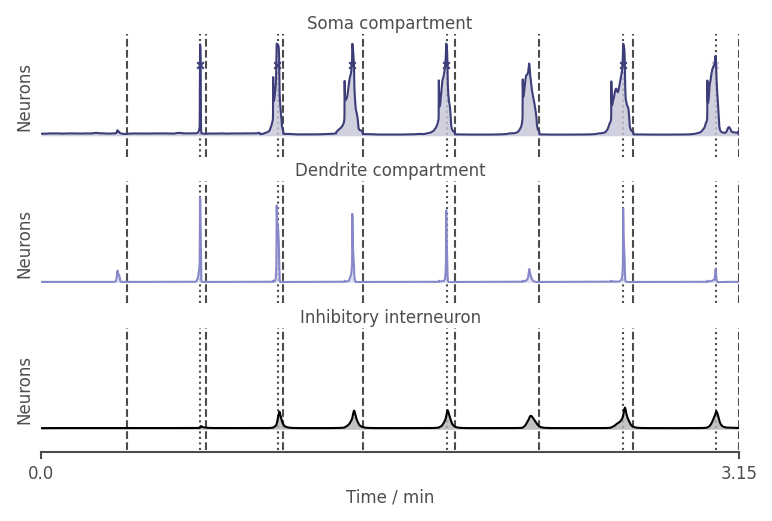

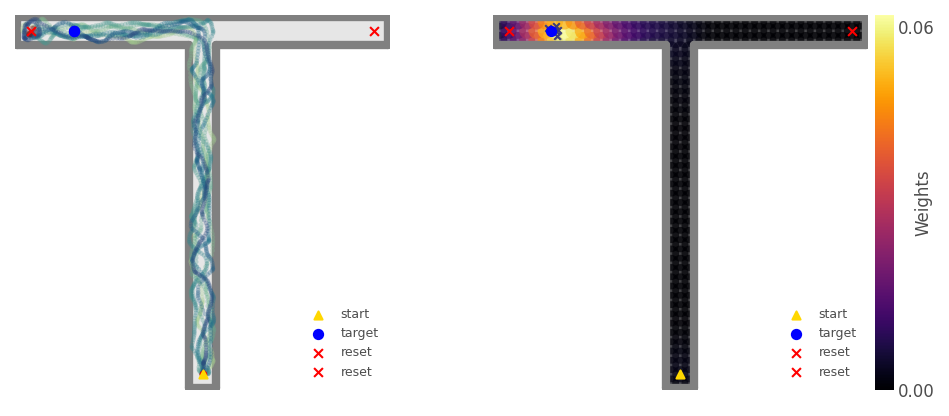

In [25]:
ts_axes = learner_low.Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner_low.Agent.plot_trajectories(scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner_low.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["3-low_inhib_timeseries"] = ts_axes
ALL_FIGURES["3-low_inhib_trajectory_weights"] = ax1D

### b. Excess dendritic self-inhibiton
BTSP is unlikely to occur.

In [26]:
HIGH_INHIBIT_WEIGHT = 8.0

Pyr_params_high = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    inhibit_weight=HIGH_INHIBIT_WEIGHT,
)

100%|██████████████████████████████████████| 6000/6000 [00:11<00:00, 500.65it/s]


Finishing last trajectory.


443it [00:00, 529.30it/s]


Only reached target 5 times (target: 12).
Trajectory lengths (9) to date: 21.48 +/- 7.74 sec each
Trajectory lengths (9) to date: 716.00 +/- 257.99 steps each
0 BTSP events triggered (allowed from steps 0 to 6443).


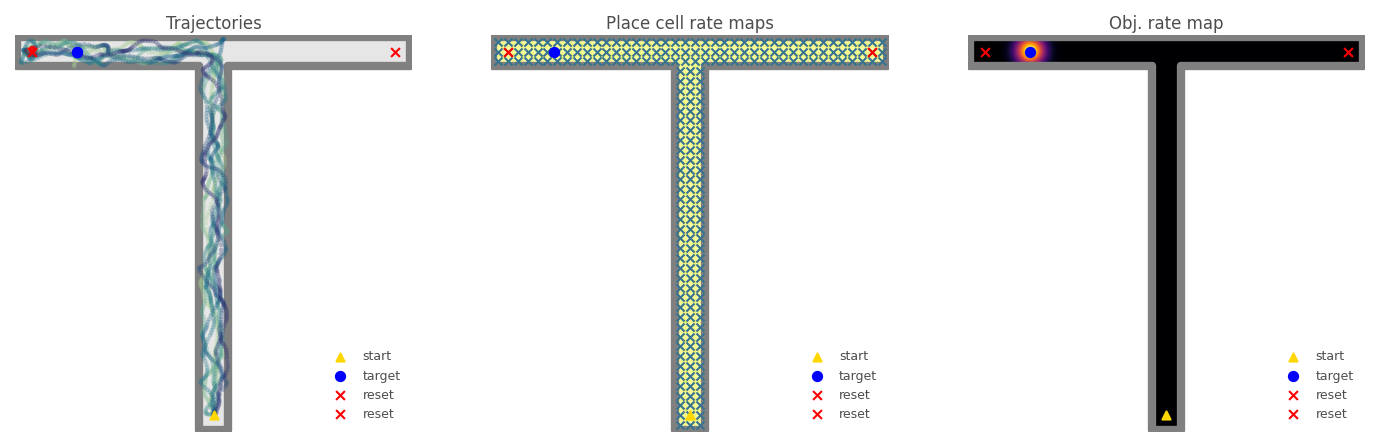

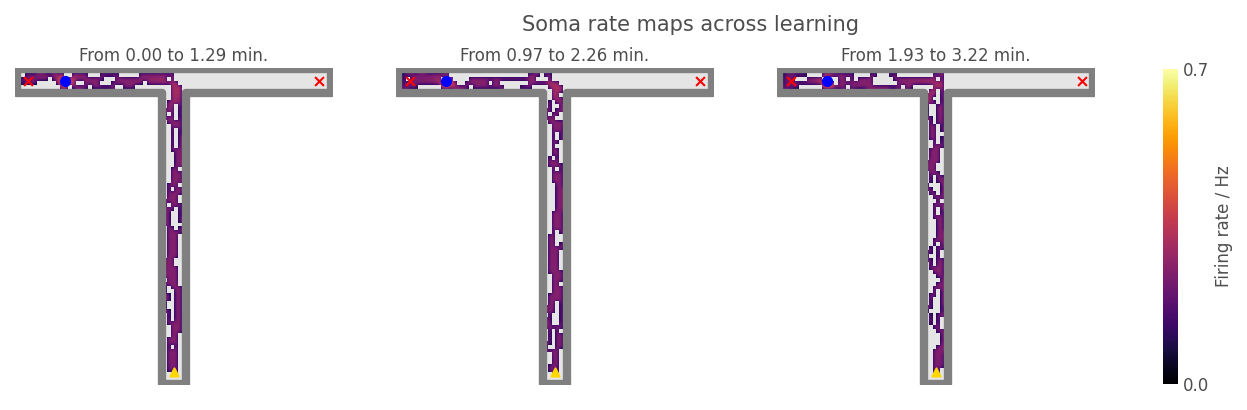

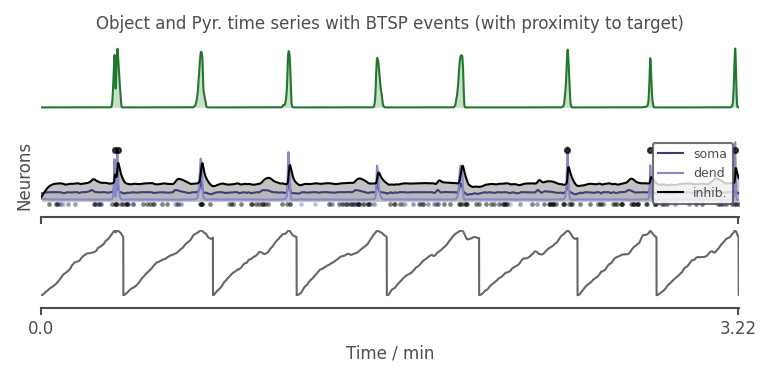

In [27]:
learner_high, spatial_axes, rate_maps_axes, BTSP_sub_ax = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params_high, 
    num_target_reaches=12, 
    max_num_steps=6000,
    use_Hebbian=False,
)

ALL_FIGURES["4-high_inhib_spatial"] = spatial_axes
ALL_FIGURES["4-high_inhib_rate_maps"] = rate_maps_axes
ALL_FIGURES["4-high_inhib_BTSP_proximity"] = BTSP_sub_ax

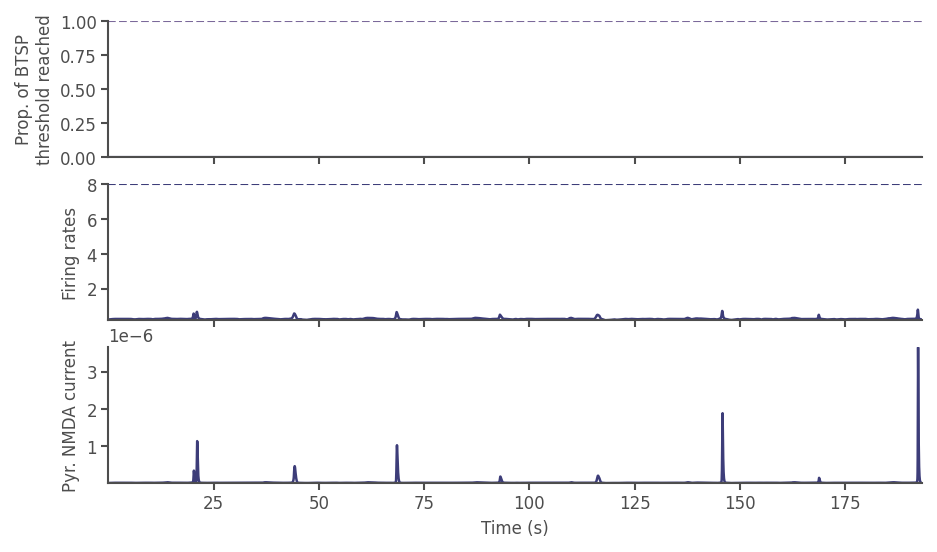

In [28]:
axes = learner_high.Pyrs.SomaCompartment.plot_BTSP_ramp()
ALL_FIGURES["4-high_inhib_BTSP_timeseries"] = axes

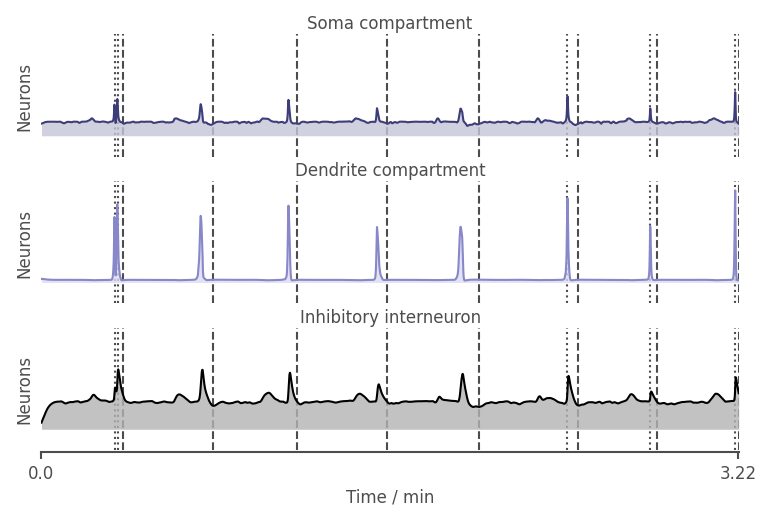

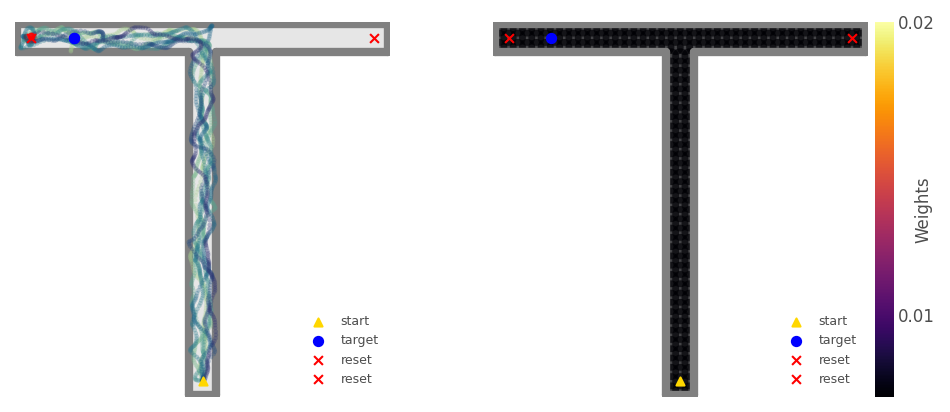

In [29]:
ts_axes = learner_high.Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner_high.Agent.plot_trajectories(scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner_high.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["4-high_inhib_timeseries"] = ts_axes
ALL_FIGURES["4-high_inhib_trajectory_weights"] = ax1D

## 4. Save

In [30]:
SAVE = True

In [31]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

Saving 32 figures...
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_spatial_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_rate_maps_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_BTSP_proximity_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_speed_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_occupancy_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_distance_to_target_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_distance_to_reset_1441.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_02_26/1-initial_PC_rate_maps_1441.png  & .svg
Figure saved to /home/cgillon/homedir/pr